# Introduction
This notebook intends to understand the data in the birdCLEF_2025 dataset and create some simple classifier models for recognizing species by their sound.

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from IPython.display import Audio
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
import time
from tqdm import tqdm
from sklearn.utils import resample
from matplotlib.colors import ListedColormap
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Load data
INPUT_PATH = 'birdclef-2025'
TRAIN_AUDIO_PATH = os.path.join(INPUT_PATH, 'train_audio')
TEST_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'test_soundscapes')
TRAIN_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'train_soundscapes')

# Load data
taxonomy = pd.read_csv(os.path.join(INPUT_PATH, 'taxonomy.csv'))
train_meta = pd.read_csv(os.path.join(INPUT_PATH, 'train.csv'))
# recording_locations = pd.read_csv(os.path.join(INPUT_PATH, 'recordming_location.txt'))

## Understanding our data

In [ ]:
print(train_meta.dtypes)
train_meta

primary_label        object
secondary_labels     object
type                 object
filename             object
collection           object
rating              float64
url                  object
latitude            float64
longitude           float64
scientific_name      object
common_name          object
author               object
license              object
dtype: object


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28559,ywcpar,[''],[''],ywcpar/iNat77392.ogg,iNat,0.0,https://static.inaturalist.org/sounds/77392.m4a,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,Yennifer Alfaro,cc-by-nc 4.0
28560,ywcpar,[''],[''],ywcpar/iNat78624.ogg,iNat,0.0,https://static.inaturalist.org/sounds/78624.wav,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,Evan Centanni,cc-by-nc-sa 4.0
28561,ywcpar,[''],[''],ywcpar/iNat789234.ogg,iNat,0.0,https://static.inaturalist.org/sounds/789234.wav,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,Henrry,cc-by 4.0
28562,ywcpar,[''],[''],ywcpar/iNat819873.ogg,iNat,0.0,https://static.inaturalist.org/sounds/819873.mp3,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,Alejandro Luy,cc-by-nc 4.0


In [ ]:
print(taxonomy.dtypes)
taxonomy # we see that taxonomy allow us to match 'primarry_lables' of train.csv to the species

primary_label      object
inat_taxon_id       int64
scientific_name    object
common_name        object
class_name         object
dtype: object


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1139490,1139490,Ragoniella pulchella,Ragoniella pulchella,Insecta
1,1192948,1192948,Oxyprora surinamensis,Oxyprora surinamensis,Insecta
2,1194042,1194042,Copiphora colombiae,Copiphora colombiae,Insecta
3,126247,126247,Leptodactylus insularum,Spotted Foam-nest Frog,Amphibia
4,1346504,1346504,Neoconocephalus brachypterus,Neoconocephalus brachypterus,Insecta
...,...,...,...,...,...
201,yehcar1,1432779,Milvago chimachima,Yellow-headed Caracara,Aves
202,yelori1,9352,Icterus nigrogularis,Yellow Oriole,Aves
203,yeofly1,16567,Tolmomyias sulphurescens,Yellow-olive Flycatcher,Aves
204,yercac1,10359,Cacicus cela,Yellow-rumped Cacique,Aves


### Preprocessing

In [ ]:
# check for duplicate rows
print(f"number of duplicate rows: {train_meta.duplicated().sum()}")

# check if secondary_label and type are empty
print("secondary_labels is empty: " + str((train_meta['secondary_labels'] == '[\'\']').all()))
print("type is empty: " + str((train_meta['type'] == "[\'\']").all()))

# check for NaN values
print(f'number of na values by column \n{train_meta.isna().sum()}')

# remove samples with unavailable locations
train_meta.dropna(inplace=True)

# remove irrelevant columns 
train_meta.drop(['rating', 'collection', 'author', 'license', 'scientific_name', 'url', 'secondary_labels', 'type'], axis=1, inplace=True)

# link the filenames to our dataset and turn secondary_labels and columns to lists
def preprocess_train_meta(df):
    # df['secondary_labels'] = df['secondary_labels'].apply(lambda x: re.findall(r"'(\w+)'", x))
    # df['type'] = df['type'].apply(lambda x: re.findall(r"'(\w+)'", x))
    df['file_path'] = df.apply(lambda row: os.path.join(TRAIN_AUDIO_PATH, row['filename']), axis=1)
    return df

train_meta = preprocess_train_meta(train_meta)

# Merge class_name from taxonomy into train_meta using primary_label as key
train_meta = train_meta.merge(taxonomy[['primary_label', 'class_name']], on='primary_label', how='left')

train_meta

number of duplicate rows: 0
secondary_labels is empty: False
type is empty: False
number of na values by column 
primary_label         0
secondary_labels      0
type                  0
filename              0
collection            0
rating                0
url                   0
latitude            809
longitude           809
scientific_name       0
common_name           0
author                0
license               0
dtype: int64


,primary_label,filename,latitude,longitude,common_name,file_path,class_name
0,1139490,1139490/CSA36385.ogg,7.3206,-73.7128,Ragoniella pulchella,birdclef-2025/train_audio/1139490/CSA36385.ogg,Insecta
1,1139490,1139490/CSA36389.ogg,7.3206,-73.7128,Ragoniella pulchella,birdclef-2025/train_audio/1139490/CSA36389.ogg,Insecta
2,1192948,1192948/CSA36358.ogg,7.3791,-73.7313,Oxyprora surinamensis,birdclef-2025/train_audio/1192948/CSA36358.ogg,Insecta
3,1192948,1192948/CSA36366.ogg,7.2800,-73.8582,Oxyprora surinamensis,birdclef-2025/train_audio/1192948/CSA36366.ogg,Insecta
4,1192948,1192948/CSA36373.ogg,7.3791,-73.7313,Oxyprora surinamensis,birdclef-2025/train_audio/1192948/CSA36373.ogg,Insecta
...,...,...,...,...,...,...,...
27750,ywcpar,ywcpar/iNat77392.ogg,7.6921,-80.3379,Yellow-crowned Parrot,birdclef-2025/train_audio/ywcpar/iNat77392.ogg,Aves
27751,ywcpar,ywcpar/iNat78624.ogg,8.9918,-79.4877,Yellow-crowned Parrot,birdclef-2025/train_audio/ywcpar/iNat78624.ogg,Aves
27752,ywcpar,ywcpar/iNat789234.ogg,9.2316,-70.2041,Yellow-crowned Parrot,birdclef-2025/train_audio/ywcpar/iNat789234.ogg,Aves
27753,ywcpar,ywcpar/iNat819873.ogg,10.5838,-66.8545,Yellow-crowned Parrot,birdclef-2025/train_audio/ywcpar/iNat819873.ogg,Aves


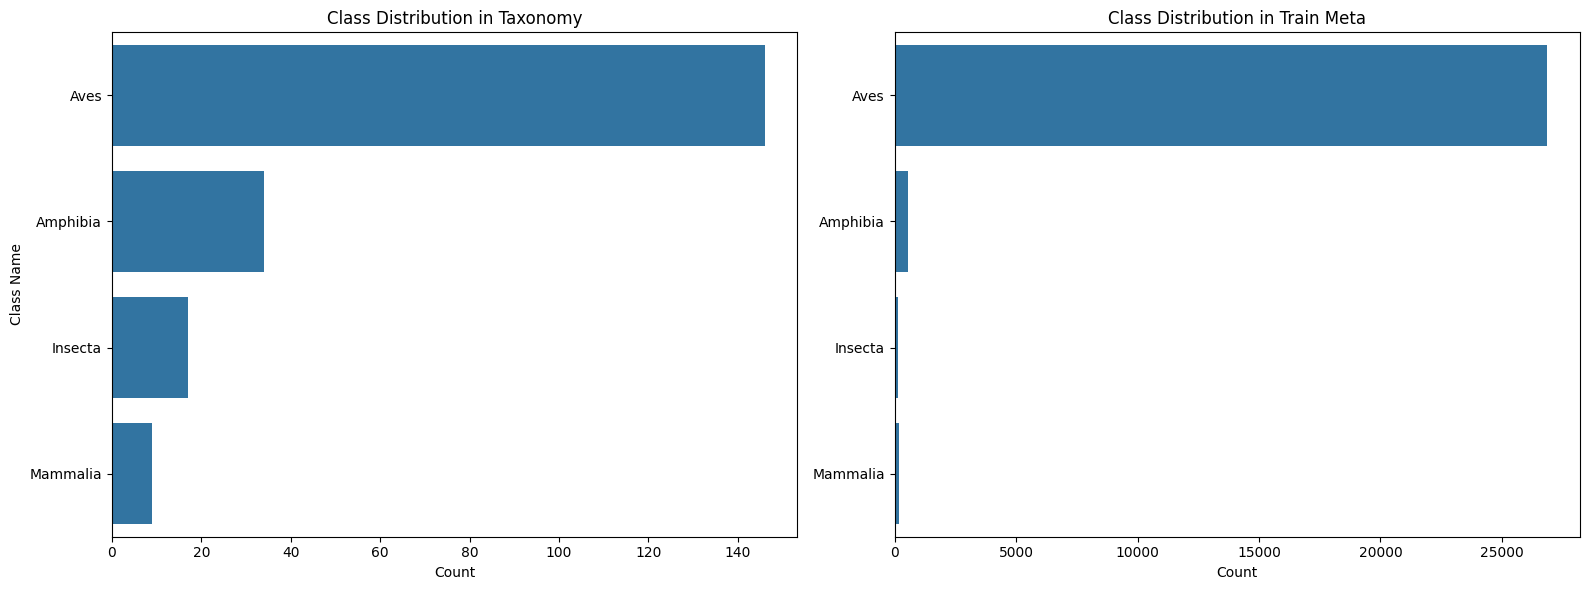

Primary label distribution of taxonomy:
class_name
Aves        146
Amphibia     34
Insecta      17
Mammalia      9
Name: count, dtype: int64 

Class distribution of train_meta:
class_name
Aves        26871
Amphibia      553
Mammalia      176
Insecta       155
Name: count, dtype: int64 

Primary label distribution of train_meta:


In [ ]:
# Create side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot for taxonomy
sns.countplot(
    data=taxonomy,
    y='class_name',
    order=taxonomy['class_name'].value_counts().index,
    ax=axs[0]
)
axs[0].set_title('Class Distribution in Taxonomy')
axs[0].set_xlabel('Count')
axs[0].set_ylabel('Class Name')

# Plot for train_meta
sns.countplot(
    data=train_meta,
    y='class_name',
    order=taxonomy['class_name'].value_counts().index,  # Same order for consistency
    ax=axs[1]
)
axs[1].set_title('Class Distribution in Train Meta')
axs[1].set_xlabel('Count')
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Primary label distribution of taxonomy:")
print(taxonomy['class_name'].value_counts(), "\n")
print("Class distribution of train_meta:")
print(train_meta['class_name'].value_counts(), "\n")
print("Primary label distribution of train_meta:")

We can see that there is a large class imbalance in the dataset. 

count
2     15
5      7
6      6
4      4
3      4
      ..
19     1
20     1
21     1
10     1
8      1
Name: count, Length: 135, dtype: int64 

Unique primary labels in train_meta: 135


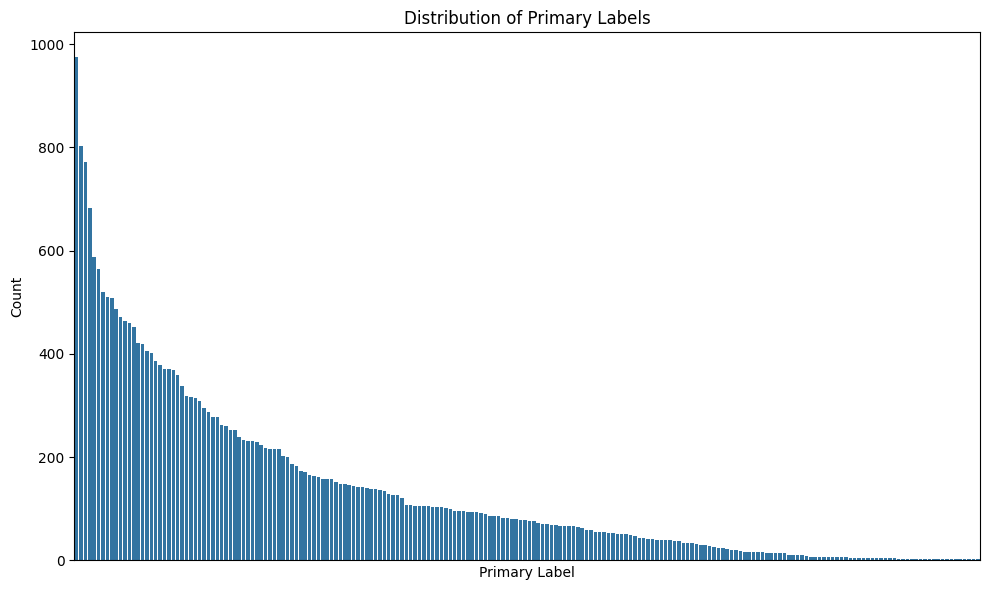

In [ ]:
label_distribution = train_meta['primary_label'].value_counts()

print(label_distribution.value_counts(), "\n")
print(f"Unique primary labels in train_meta: {label_distribution.nunique()}")\

plt.figure(figsize=(10, 6))
sns.barplot(x=label_distribution.index, y=label_distribution.values)
plt.title('Distribution of Primary Labels')
plt.xlabel('Primary Label')
plt.ylabel('Count')
plt.xticks([])
plt.tight_layout()
plt.show()

As expected, the imbalance is also significant for primary labels. 

Another problem is the large computational time for processing many audio files, so, we first decide to filter audio files based on their duration.

Measuring durations: 100%|██████████| 200/200 [00:12<00:00, 16.04it/s]


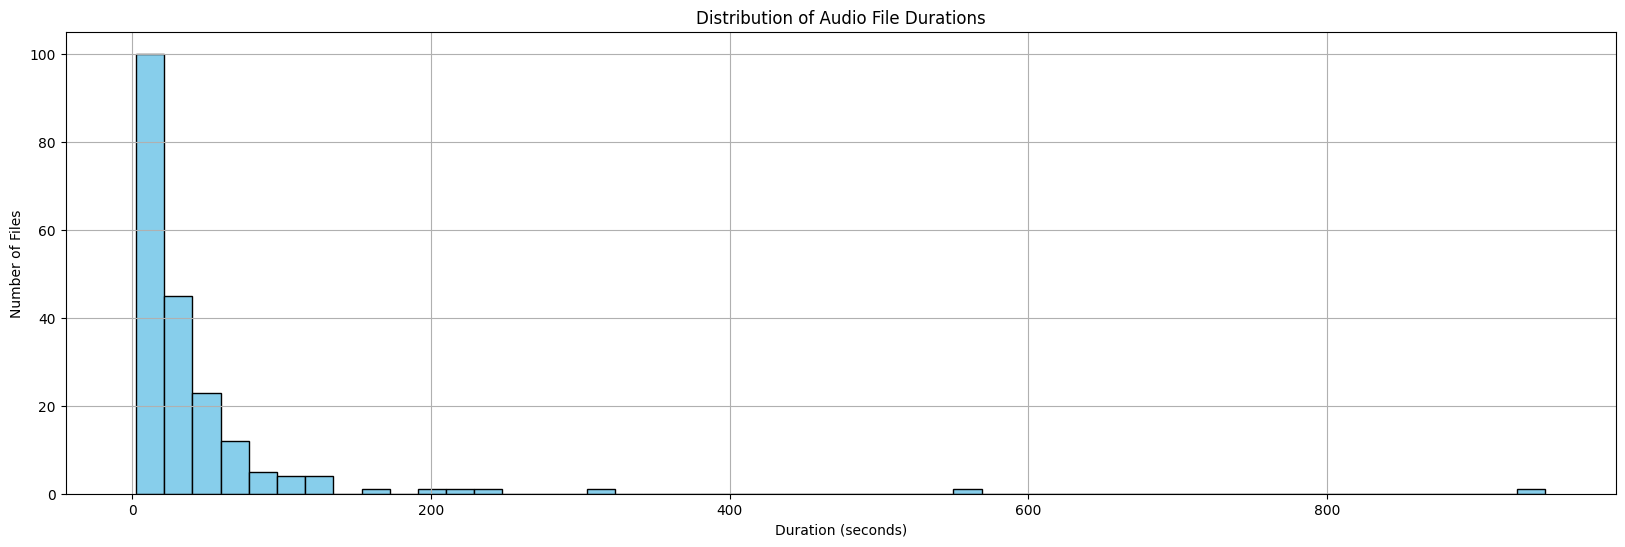

In [ ]:
# sample
sampled_meta = train_meta.sample(n=200, random_state=42)

# function to get a file's duration
def get_duration(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)  # Correct variable
        duration = librosa.get_duration(y=y, sr=sr)
        return duration
    except Exception as e:
        print(f"Could not load {file_path}: {e}")
        return None  # Use None to signify failure

# Collect durations
durations = []
for path in tqdm(sampled_meta['file_path'], desc="Measuring durations"):
    durations.append(get_duration(path))

# Plot the distribution
plt.figure(figsize=(20, 6))
plt.hist(durations, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Audio File Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.grid(True)
plt.show()

We decide to keep files between 10 and 20 seconds long.

In [ ]:
tqdm.pandas()

def filter_audio_duration(df, lower_bound, upper_bound):
    df['duration'] = df['file_path'].progress_apply(get_duration)
    df_filtered = df[
        (df['duration'] >= lower_bound) & (df['duration'] <= upper_bound)
    ].copy()
    return df_filtered

print(f"Size before filtering: {len(train_meta)}")
train_meta_filtered = filter_audio_duration(train_meta, 5, 20)
print(f"Size after filtering: {len(train_meta_filtered)}\n")

# print(f"Test set size before filtering: {len(test_df)}")
# test_df_filtered = filter_audio_duration(test_df, 5, 15)
# print(f"Test set size after filtering: {len(test_df_filtered)}\n")

# print(f"Validation set size before filtering: {len(val_df)}")
# val_df_filtered = filter_audio_duration(val_df, 5, 15)
# print(f"Validation set size after filtering: {len(val_df_filtered)}")

# Plot the filtered durations
plt.figure(figsize=(10, 6))
plt.hist(train_meta_filtered['duration'], bins=50, alpha=0.6, label='Train', color='skyblue', edgecolor='black')
# plt.hist(test_df_filtered['duration'], bins=50, alpha=0.6, label='Test', color='salmon', edgecolor='black')
# plt.hist(val_df_filtered['duration'], bins=50, alpha=0.6, label='Validation', color='yellow', edgecolor='black')
plt.title("Distribution of Audio File Durations (5 to 15 seconds)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Size before filtering: 27755


  3%|▎         | 703/27755 [00:43<27:40, 16.29it/s]  


KeyboardInterrupt: 

In [ ]:
train_meta_filtered.to_csv('filtered_duration.csv')

In [4]:
train_meta_filtered = pd.read_csv('filtered_duration.csv')

Unique primary labels in train_meta_filtered: 
primary_label
grekis     468
trokin     317
compau     306
soulap1    274
bbwduc     237
          ... 
1194042      1
134933       1
21116        1
50186        1
bubcur1      1
Name: count, Length: 190, dtype: int64

Unique primary labels in train_meta_filtered: 100


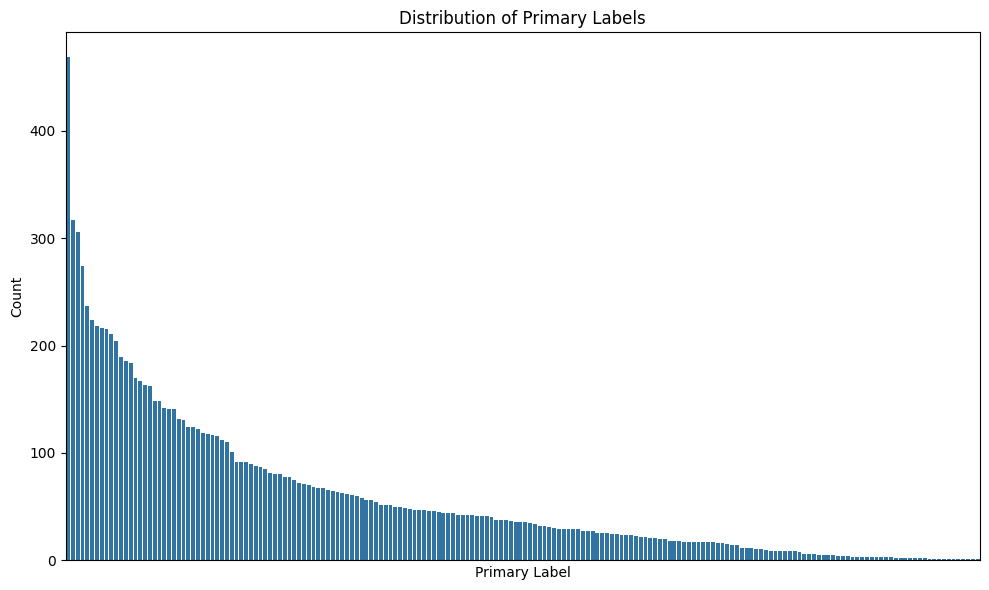

In [5]:
label_distribution = train_meta_filtered['primary_label'].value_counts()

# print(label_distribution.value_counts(), "\n")
print(f"Unique primary labels in train_meta_filtered: \n{label_distribution}\n")
print(f"Unique primary labels in train_meta_filtered: {label_distribution.nunique()}")

plt.figure(figsize=(10, 6))
sns.barplot(x=label_distribution.index, y=label_distribution.values)
plt.title('Distribution of Primary Labels')
plt.xlabel('Primary Label')
plt.ylabel('Count')
plt.xticks([])
plt.tight_layout()
plt.show()

We will also filter out species with 10 or less recordings, thus avoiding outliers and enabling stratifying.

In [ ]:
label_counts = train_meta_filtered['primary_label'].value_counts()
valid_labels = label_counts[label_counts >= 10].index
train_meta_filtered = train_meta_filtered[train_meta_filtered['primary_label'].isin(valid_labels)].reset_index(drop=True).copy()

label_distribution = train_meta_filtered['primary_label'].value_counts()
print(f"Unique primary labels in train_meta_filtered: {label_distribution.nunique()}")

Unique primary labels in train_meta_filtered: 92


At this point we would like to split the data into a training set, test set and validation set, while stratifying, so that proportions are not lost for testing. However, since we've decided to use the sound files and locations for classifying, we need to aggregate the data first.

### Feature extraction

Based on the EDA and additional research, we decided to use Mel-Frequency Cepstral Coefficients (MFCCs) to train our model.

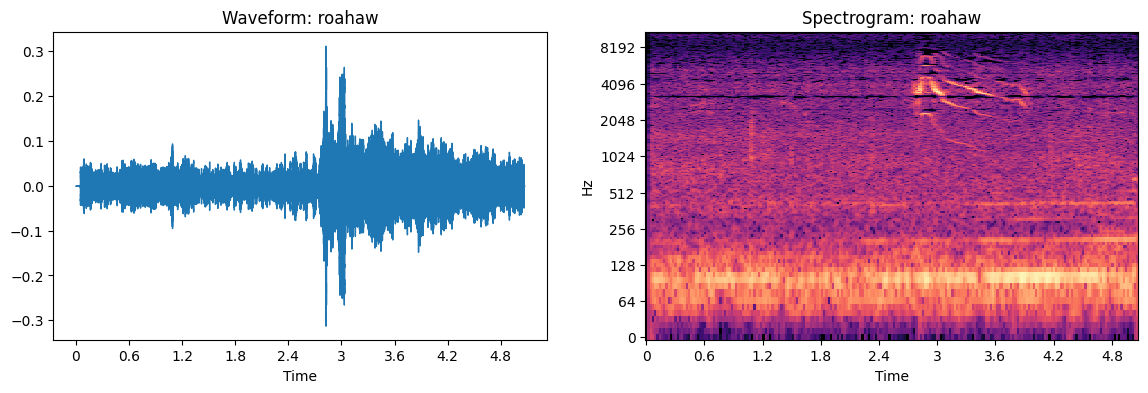

In [ ]:
# lets explore an audio file
audio_examples = train_meta.sample(1)
file_path = audio_examples['file_path'].tolist()[0]
title = audio_examples['primary_label'].tolist()[0]


Audio(file_path)
y, sr = librosa.load(file_path)
# Plot waveform
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform: " + title )

# Plot spectrogram
plt.subplot(1, 2, 2)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.title(f'Spectrogram: {title}')

plt.show()

In [ ]:
# Feature Extraction (Simple MFCC)
def extract_mfcc(file_path, sr=22050, n_mfcc=20):
    """Extracts MFCC features from an audio file."""
    try:
        y, sr = librosa.load(file_path, sr=sr)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_processed = np.mean(mfccs.T, axis=0)  # Average across time
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
    return mfccs_processed

# Example MFCC extraction
example_file = train_meta['file_path'].iloc[0]
mfccs = extract_mfcc(example_file)
print("\nMFCC Features Example:\n", mfccs)


MFCC Features Example:
 [-3.0088034e+02  1.0080163e+02  2.0586250e+01  2.5397346e+01
  1.5968860e+01  1.1692368e+01 -2.5268314e+00  3.2565429e+00
  4.2799872e-01  8.4082192e-01 -5.5912838e+00  4.9153867e+00
 -2.2406343e-01 -2.1817572e+00 -2.5627692e+00  5.9108195e+00
 -4.9044614e+00  1.4878421e+00  1.3020749e+00 -1.0821762e+00]


We extract the MFCC features, as well as the locations and aggregate them.

In [ ]:
# Feature Extraction (Simple MFCC)
def extract_mfcc(file_path, sr=22050, n_mfcc=20):
    """Extracts MFCC features from an audio file."""
    try:
        y, sr = librosa.load(file_path, sr=sr)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_processed = np.mean(mfccs.T, axis=0)  # Average across time
        return mfccs_processed
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
    

# Extract MFCC features
features = []
labels = []
valid_indices = []

for idx, row in tqdm(train_meta_filtered.iterrows(), total=len(train_meta_filtered), desc="Extracting train MFCCs"):
    mfccs = extract_mfcc(row['file_path'])
    if mfccs is not None:
        features.append(mfccs)
        labels.append(row['primary_label'])
        valid_indices.append(idx)

# Extract locations
locations = train_meta_filtered.loc[valid_indices, ['longitude', 'latitude']].values

# Concatenate audio and location features
all_features = np.hstack([np.array(features), locations])

Extracting train MFCCs: 100%|██████████| 10873/10873 [12:21<00:00, 14.66it/s]


In [ ]:
np.save('mfccs.npy', np.array(mfccs))
np.save('locations.npy', np.array(locations))
np.save('labels.npy', np.array(labels))
np.save('features.npy', np.array(all_features))

In [ ]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

np.save('labels_encoded.npy', np.array(labels_encoded))

In [ ]:
# Feature Scaling
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)

np.save('features_scaled.npy', all_features_scaled)

In [ ]:
print(len(all_features_scaled))
print(len(labels_encoded))

10873
10873


### Splitting and sampling functions

In [4]:
X = np.load('features.npy')
y = np.load('labels_encoded.npy')

In [5]:
def split(X, y, test_size=0.2, val=False, val_size=0.25):
    # train/test split
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # test/val split
    if val:
        X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=val_size, random_state=42, stratify=y_train_full)
        return X_train, y_train, X_test, y_test, X_val, y_val
    else:
        return X_train_full, y_train_full, X_test, y_test, None, None

    # Analyze label distributions
    # print("Distribution of y_train:")
    # print(pd.Series(y_train).value_counts(), "\n")

    # print("Distribution of y_val:")
    # print(pd.Series(y_val).value_counts(), "\n")

    # print("Distribution of y_test:")
    # print(pd.Series(y_test).value_counts())

In [6]:
def sample(X, y, sample_fraction=0.5, random_state=None):
    X_sample, _, y_sample, _ = train_test_split(
        X, y,
        train_size=sample_fraction,
        stratify=y,
        random_state=random_state
    )
    return X_sample, y_sample

In [7]:
def remove_classes_under(X, y, min_instances=20):
    class_counts = Counter(y)
    
    # Get valid classes
    valid_classes = {cls for cls, count in class_counts.items() if count >= min_instances}
    
    # Create mask for valid samples
    mask = np.array([label in valid_classes for label in y])
    
    # Filter X and y
    X_filtered = X[mask]
    y_filtered = y[mask]

    return X_filtered, y_filtered

## Training Models
- SVM
- Random Forest
- 

### SVM

In [6]:
# Define helper functions
def make_meshgrid(x, y, h=0.1):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    return ax.contourf(xx, yy, Z, **params)

linear train time: 1.10s
linear test time: 0.00s
linear Accuracy: 0.3621
linear Precision: 0.3996
linear Recall: 0.3621
linear F1-score: 0.3542

poly train time: 0.01s
poly test time: 0.00s
poly Accuracy: 0.1724
poly Precision: 0.2189
poly Recall: 0.1724
poly F1-score: 0.1850

rbf train time: 0.01s
rbf test time: 0.00s
rbf Accuracy: 0.1552
rbf Precision: 0.1498
rbf Recall: 0.1552
rbf F1-score: 0.1386

sigmoid train time: 0.01s
sigmoid test time: 0.00s
sigmoid Accuracy: 0.1379
sigmoid Precision: 0.1513
sigmoid Recall: 0.1379
sigmoid F1-score: 0.1271



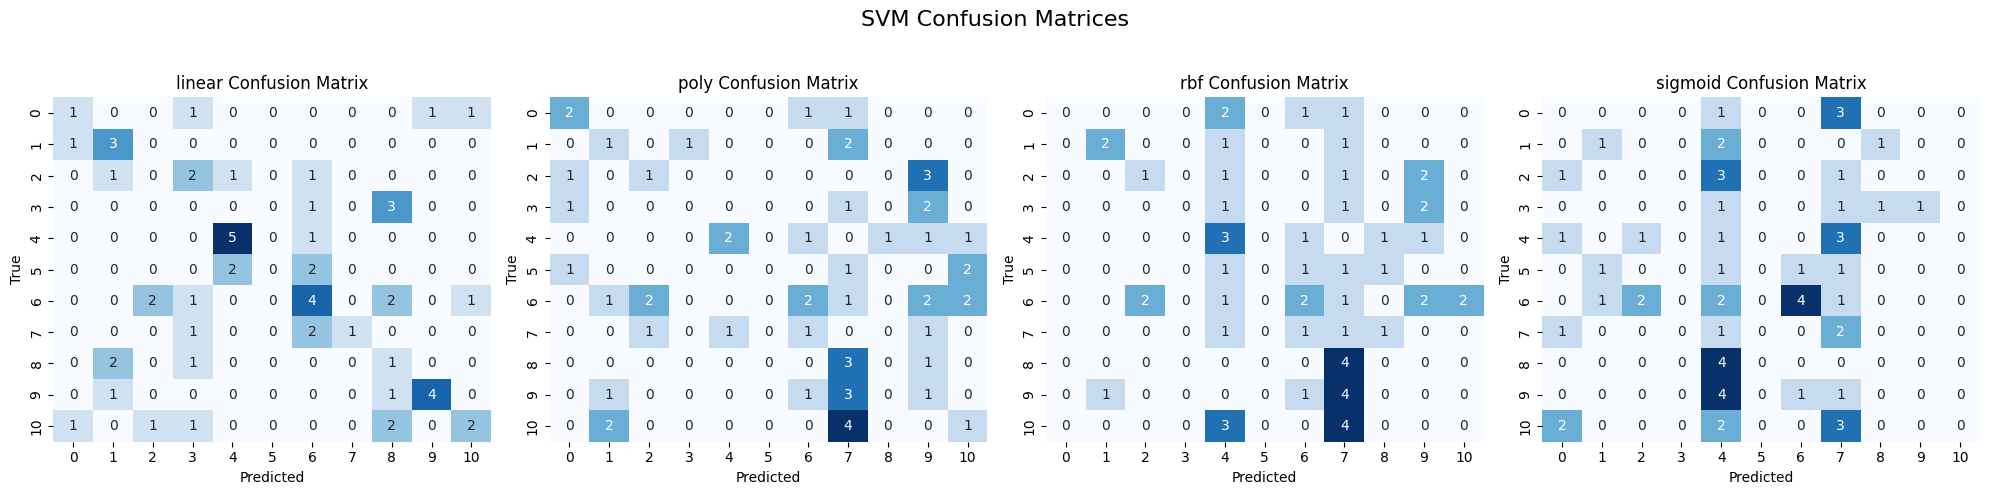

In [ ]:
def train_SVM_model(X, y, kernel_list=['linear', 'poly', 'rbf', 'sigmoid']):
    # Sample and clean
    X_sampled, y_sampled = sample(X, y, 0.1)
    X_sampled, y_sampled = remove_classes_under(X_sampled, y_sampled, min_instances=20)

    # Split
    X_train, y_train, X_test, y_test, X_val, y_val = split(X_sampled, y_sampled)

    # Resample
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    fig_cm, axes_cm = plt.subplots(1, len(kernel_list), figsize=(5 * len(kernel_list), 5))

    for idx, kernel in enumerate(kernel_list):
        clf = SVC(kernel=kernel, degree=2, class_weight='balanced')

        # Train
        start_train = time.time()
        clf.fit(X_train, y_train)
        print(f"{kernel} train time: {time.time() - start_train:.2f}s")

        # Predict
        start_test = time.time()
        y_pred = clf.predict(X_test)
        print(f"{kernel} test time: {time.time() - start_test:.2f}s")

        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
        print(f"{kernel} Accuracy: {acc:.4f}")
        print(f"{kernel} Precision: {prec:.4f}")
        print(f"{kernel} Recall: {rec:.4f}")
        print(f"{kernel} F1-score: {f1:.4f}\n")

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        ax_cm = axes_cm[idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, cbar=False)
        ax_cm.set_title(f"{kernel} Confusion Matrix")
        ax_cm.set_xlabel("Predicted")
        ax_cm.set_ylabel("True")

    fig_cm.suptitle("SVM Confusion Matrices", fontsize=16)
    fig_cm.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

train_SVM_model(X, y)

### Naive Bayes

GNB train time: 0.00s
GNB test time: 0.00s
GNB Accuracy: 0.3103
GNB Precision: 0.3115
GNB Recall: 0.3103
GNB F1-score: 0.2893



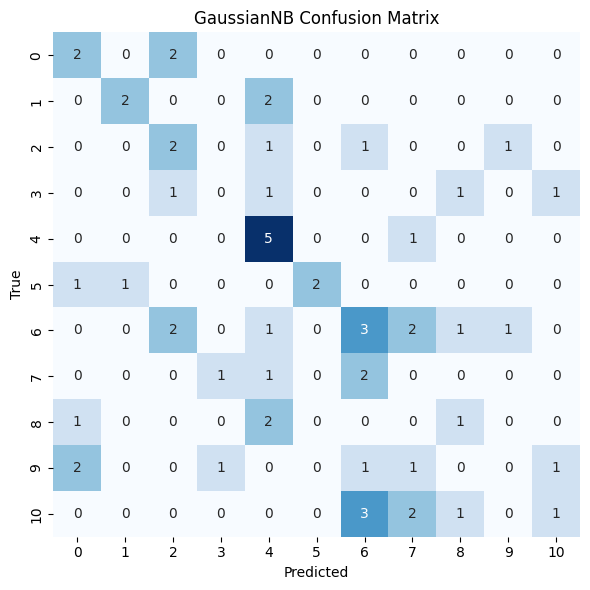

In [ ]:
def train_GNB_model(X, y):

    # Sample and clean
    X_sampled, y_sampled = sample(X, y, 0.1)
    X_sampled, y_sampled = remove_classes_under(X_sampled, y_sampled, min_instances=20)

    # Split
    X_train, y_train, X_test, y_test, X_val, y_val = split(X_sampled, y_sampled)

    # Resample
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Train model
    model = GaussianNB()
    start_train = time.time()
    model.fit(X_train, y_train)
    print(f"GNB train time: {time.time() - start_train:.2f}s")

    # Predict
    start_test = time.time()
    y_pred = model.predict(X_test)
    print(f"GNB test time: {time.time() - start_test:.2f}s")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    print(f"GNB Accuracy: {acc:.4f}")
    print(f"GNB Precision: {prec:.4f}")
    print(f"GNB Recall: {rec:.4f}")
    print(f"GNB F1-score: {f1:.4f}\n")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, cbar=False)
    ax_cm.set_title("GaussianNB Confusion Matrix")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("True")
    plt.tight_layout()
    plt.show()

train_GNB_model(X, y)


### KNN

KNN train time: 0.00s
KNN test time: 0.00s
KNN Accuracy: 0.2414
KNN Precision: 0.3425
KNN Recall: 0.2414
KNN F1-score: 0.2608



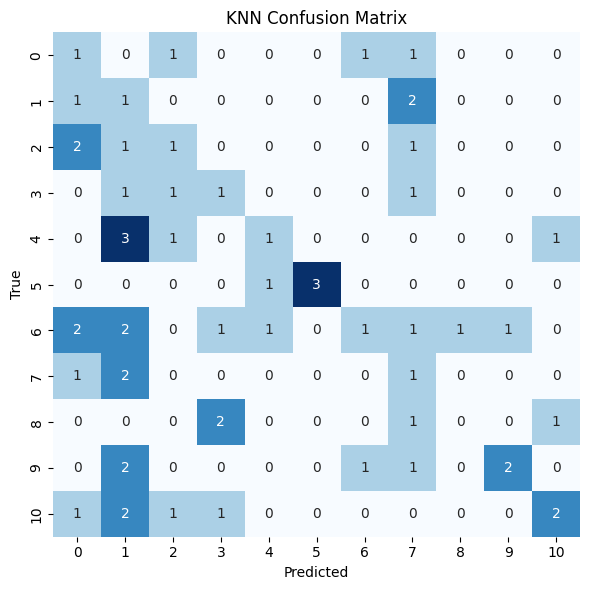

In [37]:
def train_KNN_model(X, y):

    # Sample and clean
    X_sampled, y_sampled = sample(X, y, 0.1)
    X_sampled, y_sampled = remove_classes_under(X_sampled, y_sampled, min_instances=20)

    # Split
    X_train, y_train, X_test, y_test, X_val, y_val = split(X_sampled, y_sampled)

    # Resample
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Train model
    model = KNeighborsClassifier(n_neighbors=3, p=1)
    start_train = time.time()
    model.fit(X_train, y_train)
    print(f"KNN train time: {time.time() - start_train:.2f}s")

    # Predict
    start_test = time.time()
    y_pred = model.predict(X_test)
    print(f"KNN test time: {time.time() - start_test:.2f}s")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    print(f"KNN Accuracy: {acc:.4f}")
    print(f"KNN Precision: {prec:.4f}")
    print(f"KNN Recall: {rec:.4f}")
    print(f"KNN F1-score: {f1:.4f}\n")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, cbar=False)
    ax_cm.set_title("KNN Confusion Matrix")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("True")
    plt.tight_layout()
    plt.show()

train_KNN_model(X, y)

### Random Forest

In [ ]:
# Model Training (XGBoost or LightGBM)
def train_GB_model(train_meta, model_type='xgboost', n_samples=500, n_mfcc=20):
    """Trains a XGBoost or LightGBM model."""
    # Sample a subset of data for faster training
    train_subset = train_meta.sample(n_samples, random_state=42)

    # Extract MFCC features
    features = []
    labels = []
    for index, row in train_subset.iterrows():
        mfccs = extract_mfcc(row['file_path'], n_mfcc=n_mfcc)
        if mfccs is not None:
            features.append(mfccs)
            labels.append(row['primary_label'])

    X = np.array(features)
    y = np.array(labels)

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    if model_type == 'xgboost':
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) #added eval_metric as it is needed
        model.fit(X_train, y_train)

    elif model_type == 'lightgbm':
        model = lgb.LGBMClassifier(random_state=42)
        model.fit(X_train, y_train)

    else:
        raise ValueError("Invalid model_type. Choose 'xgboost' or 'lightgbm'.")

    return model, X_test, y_test, y_train

#Choose between 'xgboost' or 'lightgbm'
model, X_test, y_test, y_train = train_GB_model(train_meta, model_type='lightgbm') #or 'xgboost'

KeyboardInterrupt: 

In [ ]:
# model evaluations

fpr, tpr, thresholds = roc_curve(y_true, y_score)


Sources:
- https://www.kaggle.com/code/jocelyndumlao/birdclef-2025-mfcc-feature-roc-auc-analysis#Import-Libraries (24.05.2025)
- https://github.com/UtrechtUniversity/animal-sounds (24.05.2025)
- https://www.kaggle.com/competitions/birdclef-2025/discussion/572928 (24.05.2025)